# 08 — Adjustments & Data Gaps (Blocks G & H)
## REVER Logistics Cost & Revenue Analysis — 2025

Answers Block G (adjustment analysis) and Block H (data integrity gaps).

**Requires:** `01_preparacion.ipynb` to have been run first.

In [10]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings("ignore")

PROCESSED = Path("../processed")
PALETTE = {
    "primary": "#2C5F8A", "positive": "#2A9D8F", "negative": "#E63946",
    "neutral": "#ADB5BD", "accent": "#F4A261", "bg": "#FFFFFF", "grid": "#F0F0F0",
}
CARRIER_COLORS = {
    "Correos": "#F4A261", "Correos Express": "#E63946",
    "UPS": "#8B5E3C", "GLS": "#2A9D8F", "BRT": "#457B9D",
}
plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"], "axes.facecolor": PALETTE["bg"],
    "axes.grid": True, "grid.color": PALETTE["grid"], "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": True, "axes.spines.bottom": True,
    "axes.edgecolor": "#CCCCCC", "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.frameon": False, "legend.fontsize": 10,
    "figure.dpi": 110, "figure.figsize": (14, 5),
})
FIG_W, FIG_H = 14, 5

merged  = pd.read_parquet(PROCESSED / "merged.parquet")
matched = merged.dropna(subset=["rever_revenue_net"]).copy()
adj     = pd.read_parquet(PROCESSED / "adj.parquet")
rever   = pd.read_parquet(PROCESSED / "rever.parquet")

print(f"merged : {len(merged):,} | matched: {len(matched):,} | adj: {len(adj):,}")

merged : 255,230 | matched: 244,149 | adj: 120,859


---
## G1 — Adjustment types: total cost ranking

Which adjustment types cost the most in total?
Each type (Weight Adjustment, Peak Surcharge, Remote Area, etc.) is ranked by total billed amount.

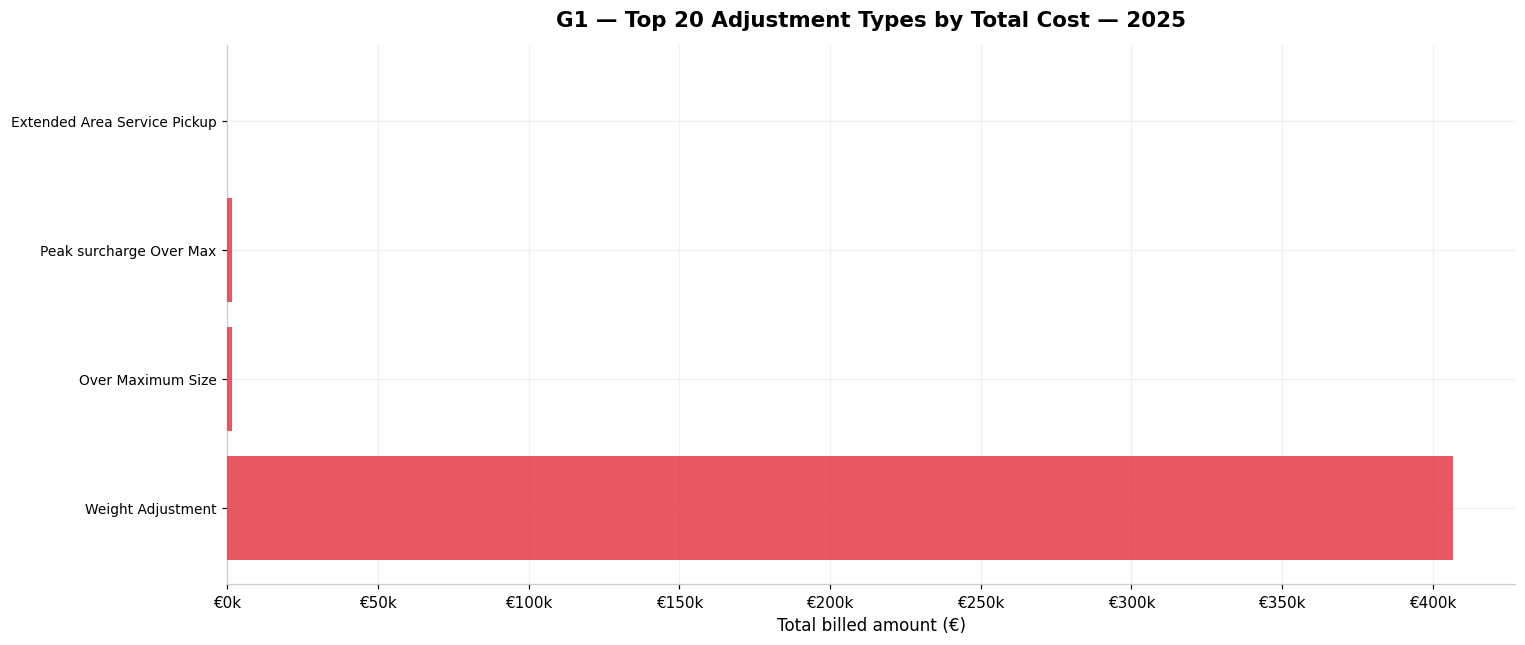

In [11]:
# ── G1: Adjustment type ranking ───────────────────────────────────────────────
adj_type = (
    adj.groupby("type")["subtotal"]
    .agg(total_cost="sum", count="count")
    .reset_index()
    .sort_values("total_cost", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 1))
bar_colors = [PALETTE["negative"] if i < 5 else PALETTE["accent"] if i < 10 else PALETTE["neutral"]
              for i in range(len(adj_type))]
ax.barh(range(len(adj_type)), adj_type["total_cost"], color=bar_colors, alpha=0.85, zorder=3)
ax.set_yticks(range(len(adj_type)))
ax.set_yticklabels(adj_type["type"], fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1_000:.0f}k"))
ax.set_xlabel("Total billed amount (€)")
ax.set_title("G1 — Top 20 Adjustment Types by Total Cost — 2025", pad=12)
plt.tight_layout()
plt.show()

---
## G1 (why) — Adjustment types by carrier

Each carrier has different surcharge policies. This shows which adjustment types each carrier bills most,
enabling targeted contract negotiation.

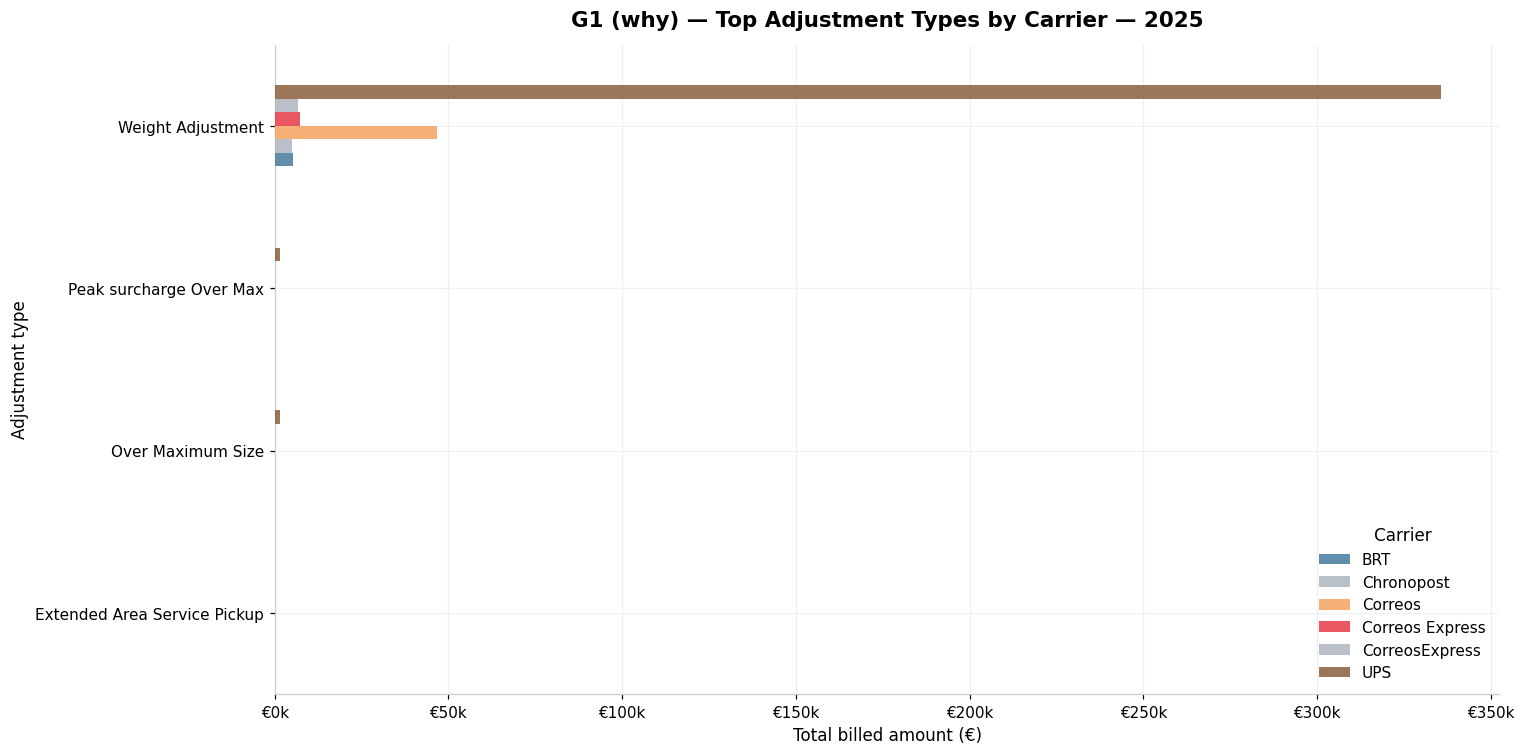

In [12]:
# ── G1 (why): Adjustment types by carrier ─────────────────────────────────────
adj_carrier = (
    adj.groupby(["carrier", "type"])["subtotal"].sum().reset_index()
    .sort_values("subtotal", ascending=False)
)
# Top 8 types per carrier for readability
top_types = adj_carrier.groupby("type")["subtotal"].sum().sort_values(ascending=False).head(8).index
adj_carrier_top = adj_carrier[adj_carrier["type"].isin(top_types)]
pivot_adj = adj_carrier_top.pivot(index="type", columns="carrier", values="subtotal").fillna(0)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 2))
pivot_adj.plot(kind="barh", ax=ax,
               color=[CARRIER_COLORS.get(c, PALETTE["neutral"]) for c in pivot_adj.columns],
               alpha=0.85, zorder=3)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1_000:.0f}k"))
ax.set_xlabel("Total billed amount (€)")
ax.set_ylabel("Adjustment type")
ax.legend(title="Carrier", loc="lower right")
ax.set_title("G1 (why) — Top Adjustment Types by Carrier — 2025", pad=12)
plt.tight_layout()
plt.show()

---
## H1 — Cost gap: carrier cost without REVER revenue

These are shipments the carrier billed REVER but REVER never charged the merchant.
Pure absorbed cost. How much? By which carrier?

        carrier  shipments  absorbed_cost  pct_of_carrier
            GLS        256      167956.05      100.000000
            UPS       3302       55139.93        2.770134
        Correos       5112       17068.77        4.923290
Correos Express       2411       10482.07        7.548292


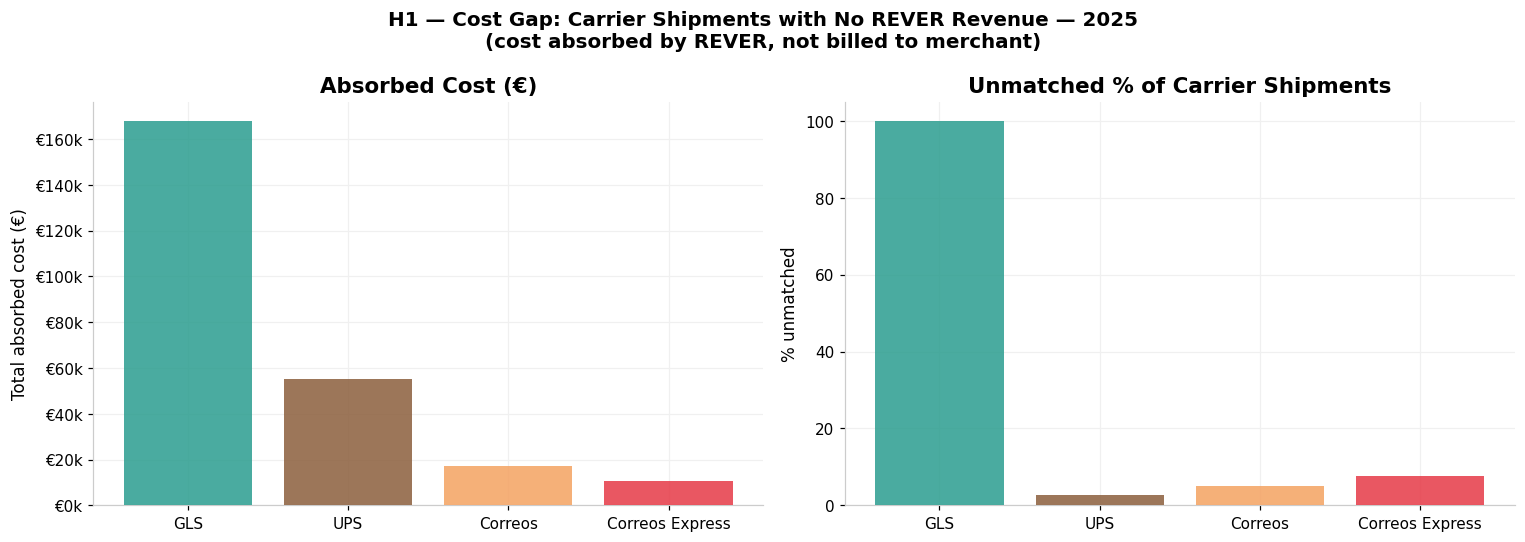

In [13]:
# ── H1: Unmatched shipments (carrier cost, no REVER revenue) ──────────────────
unmatched = merged[merged["rever_revenue_net"].isna()].copy()

h1 = (
    unmatched.groupby("carrier")
    .agg(shipments=("tracking_id", "count"), absorbed_cost=("carrier_cost_net", "sum"))
    .reset_index()
    .sort_values("absorbed_cost", ascending=False)
)
h1["pct_of_carrier"] = h1.apply(
    lambda r: r["shipments"] / len(merged[merged["carrier"] == r["carrier"]]) * 100, axis=1
)
print(h1.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))
colors_h1 = [CARRIER_COLORS.get(c, PALETTE["neutral"]) for c in h1["carrier"]]

axes[0].bar(h1["carrier"], h1["absorbed_cost"], color=colors_h1, alpha=0.85, zorder=3)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1_000:.0f}k"))
axes[0].set_title("Absorbed Cost (€)")
axes[0].set_ylabel("Total absorbed cost (€)")

axes[1].bar(h1["carrier"], h1["pct_of_carrier"], color=colors_h1, alpha=0.85, zorder=3)
axes[1].set_title("Unmatched % of Carrier Shipments")
axes[1].set_ylabel("% unmatched")
for ax in axes:
    ax.set_xlabel("")

fig.suptitle("H1 — Cost Gap: Carrier Shipments with No REVER Revenue — 2025\n(cost absorbed by REVER, not billed to merchant)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## H2 — Revenue without carrier record

Shipments in REVER's invoice that have no matching carrier cost.
Could be missing carrier data, BRT shipments (not joinable), or billing errors.

REVER shipments with no carrier record: 52,081
  Revenue at risk                     : €319,797

  return_method  shipments  total_revenue
 DROP_OFF_POINT      38853    242661.9866
   HOME_PICK_UP      13069     76033.8265
DELIVERY_PICKUP        159      1100.9500


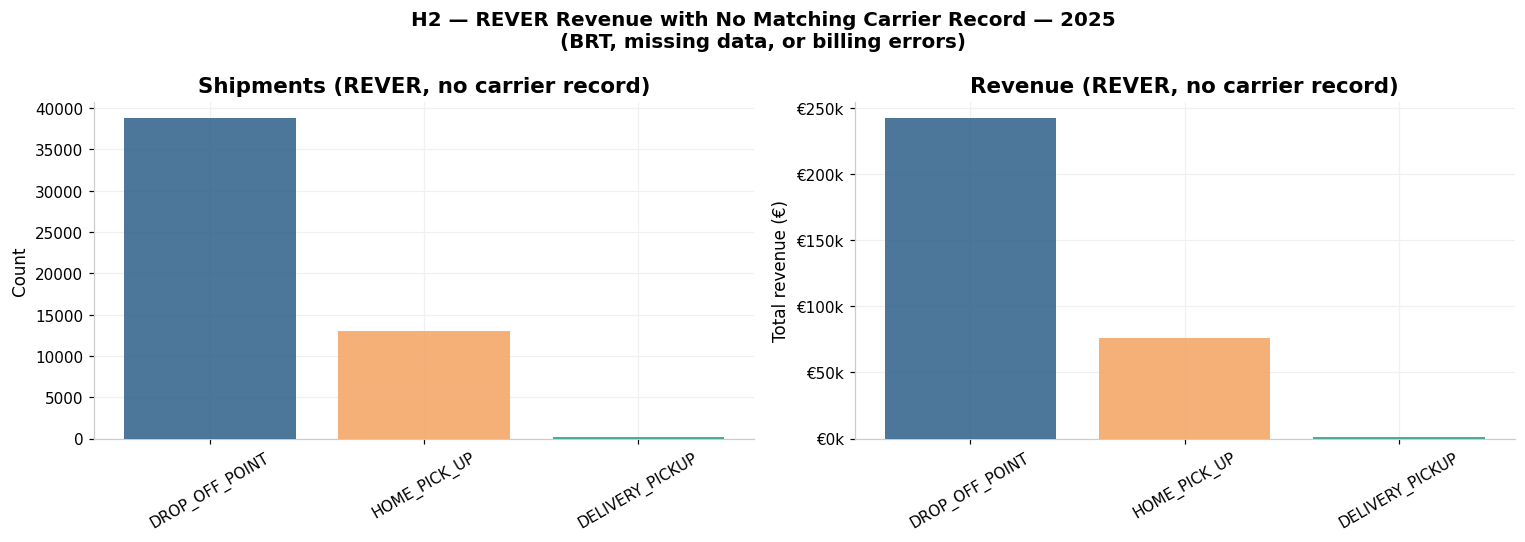

In [14]:
# ── H2: REVER revenue with no carrier record ──────────────────────────────────
# Anti-join: REVER tracking IDs that did not appear in carrier_master
# Note: rever.parquet has no 'carrier' column — group by 'return_method' instead
carrier_tracking = set(merged["tracking_id"].dropna().unique())
rever_only = rever[~rever["tracking_id"].isin(carrier_tracking)].copy()

h2_by_method = (
    rever_only.groupby("return_method")["subtotal"]
    .agg(shipments="count", total_revenue="sum")
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)
print(f"REVER shipments with no carrier record: {len(rever_only):,}")
print(f"  Revenue at risk                     : €{rever_only['subtotal'].sum():,.0f}")
print()
print(h2_by_method.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))
colors_h2 = [PALETTE["primary"], PALETTE["accent"], PALETTE["positive"],
             PALETTE["negative"], PALETTE["neutral"]][:len(h2_by_method)]

axes[0].bar(h2_by_method["return_method"], h2_by_method["shipments"],
            color=colors_h2, alpha=0.85, zorder=3)
axes[0].set_title("Shipments (REVER, no carrier record)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(h2_by_method["return_method"], h2_by_method["total_revenue"],
            color=colors_h2, alpha=0.85, zorder=3)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1_000:.0f}k"))
axes[1].set_title("Revenue (REVER, no carrier record)")
axes[1].set_ylabel("Total revenue (€)")
axes[1].tick_params(axis="x", rotation=30)

fig.suptitle("H2 — REVER Revenue with No Matching Carrier Record — 2025\n(BRT, missing data, or billing errors)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## H3 — Duplicate tracking IDs

Are there duplicate `tracking_id` values in the REVER dataset or in each carrier's dataset?
Duplicates inflate costs or revenue and distort all margin calculations.

REVER duplicates    : 586 tracking IDs (4,543 total rows)
Carrier duplicates  : 2,203 tracking IDs (4,501 total rows)

        carrier  duplicate_rows
            UPS            4222
            GLS             174
        Correos              81
Correos Express              24


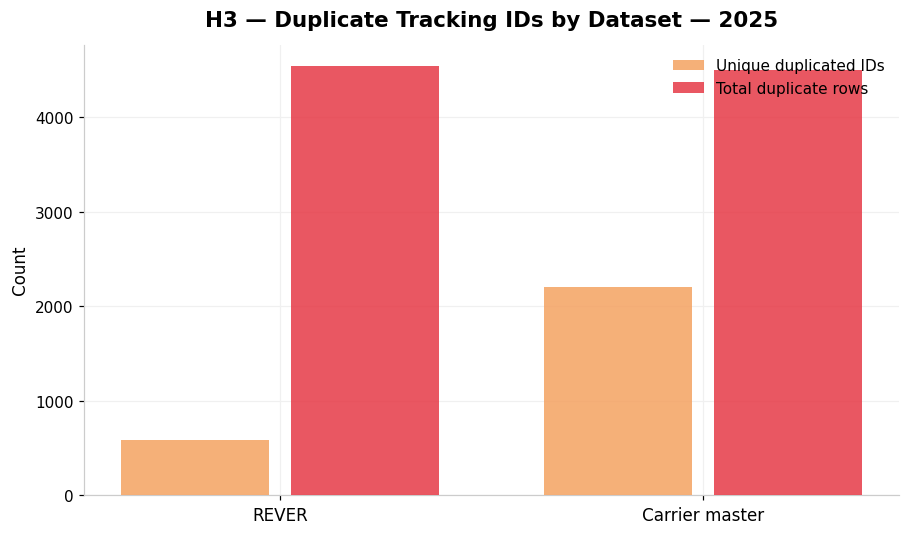

In [15]:
# ── H3: Duplicate tracking IDs ────────────────────────────────────────────────
dup_rever = rever[rever.duplicated("tracking_id", keep=False)].copy()
dup_carrier = merged[merged.duplicated("tracking_id", keep=False)].copy()

dup_by_carrier = (
    dup_carrier.groupby("carrier")["tracking_id"]
    .count()
    .reset_index()
    .rename(columns={"tracking_id": "duplicate_rows"})
    .sort_values("duplicate_rows", ascending=False)
)

print(f"REVER duplicates    : {dup_rever['tracking_id'].nunique():,} tracking IDs "
      f"({len(dup_rever):,} total rows)")
print(f"Carrier duplicates  : {dup_carrier['tracking_id'].nunique():,} tracking IDs "
      f"({len(dup_carrier):,} total rows)")
print()
print(dup_by_carrier.to_string(index=False))

summary = pd.DataFrame({
    "Dataset": ["REVER", "Carrier master"],
    "Unique duplicated IDs": [dup_rever["tracking_id"].nunique(), dup_carrier["tracking_id"].nunique()],
    "Total duplicate rows": [len(dup_rever), len(dup_carrier)],
})

fig, ax = plt.subplots(figsize=(FIG_W * 0.6, FIG_H))
x = range(len(summary))
ax.bar([i - 0.2 for i in x], summary["Unique duplicated IDs"],
       width=0.35, color=PALETTE["accent"], alpha=0.85, label="Unique duplicated IDs", zorder=3)
ax.bar([i + 0.2 for i in x], summary["Total duplicate rows"],
       width=0.35, color=PALETTE["negative"], alpha=0.85, label="Total duplicate rows", zorder=3)
ax.set_xticks(list(x))
ax.set_xticklabels(summary["Dataset"], fontsize=11)
ax.set_ylabel("Count")
ax.legend()
ax.set_title("H3 — Duplicate Tracking IDs by Dataset — 2025", pad=12)
plt.tight_layout()
plt.show()

---
## H4 — GLS cost detail: nature and distribution

GLS has 256 shipments at an average of €656/shipment (135x more than BRT).
This cell breaks down cost distribution and monthly pattern to determine
whether this is a few extreme outliers or a systematically different type of contract.

GLS total rows      : 256
GLS total cost      : €167,956
GLS avg/shipment    : €656.08
GLS min / max       : €10.73 / €7,643
GLS match rate      : 0.0%

GLS by month:
  month  shipments  total_cost    avg_cost
2025-04         66     3151.42   47.748788
2025-05         29     1326.35   45.736207
2025-07         62     1769.54   28.540968
2025-08         48     1667.74   34.744583
2025-09         24    69030.00 2876.250000
2025-10         27    91011.00 3370.777778

Cost buckets:
                  count        sum
carrier_cost_net                  
€0–50               174    4569.10
€50–200              32    3013.95
€200–500              1     444.00
€500–1k               2    1303.00
€1k+                 47  158626.00


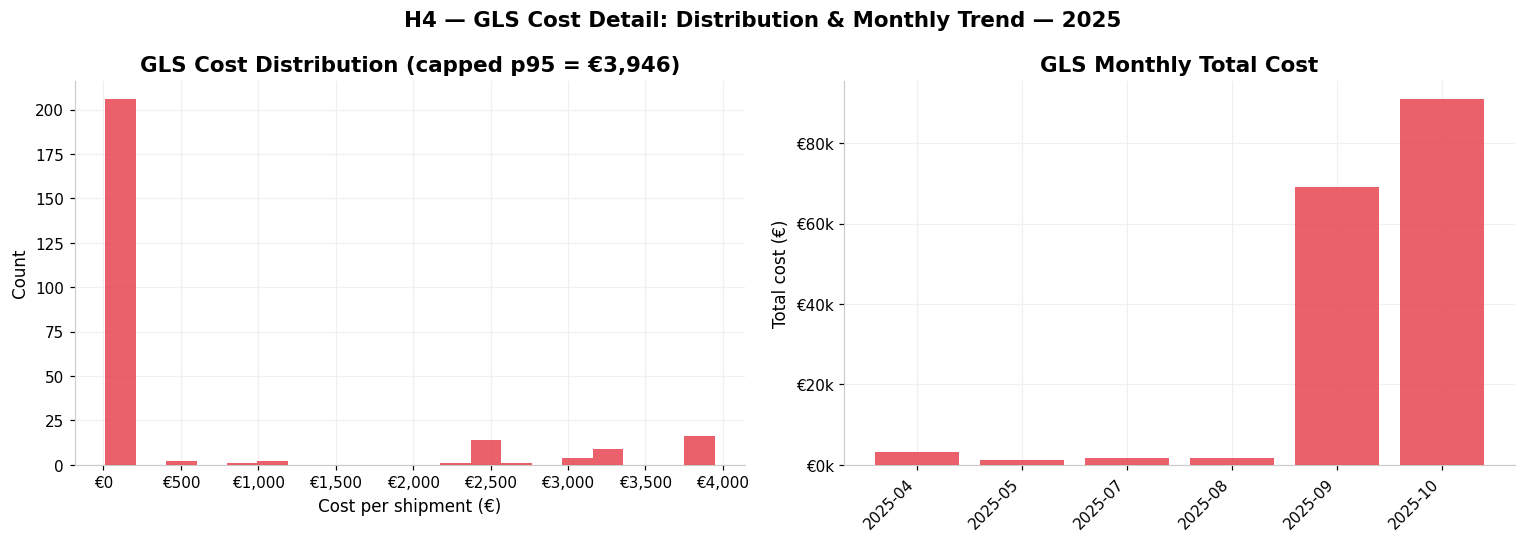

In [16]:
# ── H4: GLS cost detail — distribution and monthly trend ──────────────────────
gls_all = merged[merged["carrier"] == "GLS"].copy()

print(f"GLS total rows      : {len(gls_all):,}")
print(f"GLS total cost      : €{gls_all['carrier_cost_net'].sum():,.0f}")
print(f"GLS avg/shipment    : €{gls_all['carrier_cost_net'].mean():,.2f}")
print(f"GLS min / max       : €{gls_all['carrier_cost_net'].min():.2f} / €{gls_all['carrier_cost_net'].max():,.0f}")
print(f"GLS match rate      : {gls_all['rever_revenue_net'].notna().mean()*100:.1f}%")
print()

gls_month = (
    gls_all.groupby("month")["carrier_cost_net"]
    .agg(shipments="count", total_cost="sum", avg_cost="mean")
    .reset_index()
)
print("GLS by month:")
print(gls_month.to_string(index=False))
print()

buckets = pd.cut(gls_all["carrier_cost_net"],
                 bins=[0, 50, 200, 500, 1000, 10000],
                 labels=["€0–50", "€50–200", "€200–500", "€500–1k", "€1k+"])
print("Cost buckets:")
print(gls_all.groupby(buckets)["carrier_cost_net"].agg(["count", "sum"]).to_string())

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))
cap95 = gls_all["carrier_cost_net"].quantile(0.95)
axes[0].hist(gls_all["carrier_cost_net"].clip(upper=cap95),
             bins=20, color=PALETTE["negative"], alpha=0.8, zorder=3)
axes[0].set_title(f"GLS Cost Distribution (capped p95 = €{cap95:,.0f})")
axes[0].set_xlabel("Cost per shipment (€)")
axes[0].set_ylabel("Count")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:,.0f}"))

axes[1].bar(gls_month["month"], gls_month["total_cost"],
            color=PALETTE["negative"], alpha=0.8, zorder=3)
axes[1].set_xticklabels(gls_month["month"], rotation=45, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1_000:.0f}k"))
axes[1].set_title("GLS Monthly Total Cost")
axes[1].set_ylabel("Total cost (€)")

fig.suptitle("H4 — GLS Cost Detail: Distribution & Monthly Trend — 2025", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## H5 — Duplicate tracking IDs: double-billing risk audit

586 tracking IDs appear more than once in REVER's invoicing.
This cell separates two risk types:
- **Multi-period duplicates:** same ID billed in different months → potential double-charging the merchant
- **Same-period duplicates:** multiple rows in same month → processing error

Quantifies the excess revenue at risk for each type.

Duplicate tracking IDs total: 586

Multi-period (re-invoice risk): 15 IDs
  Total billed  : €186
  Excess billed : €97  ← potential double-billing

Same-period (processing dup): 571 IDs
  Excess billed : €9,783

Total excess revenue at risk: €9,879

Top 10 by excess billed:
       tracking_id  occurrences  total_billed  excess_billed  n_periods
1Z7631W88613311110            4       363.000       272.2500          1
1Z7631W88624385922            4       363.000       272.2500          1
1Z7631W89111764303            4       220.946       165.7095          1
1Z7631W89108741183            4       220.946       165.7095          1
1Z7631W89103034287            4       220.946       165.7095          1
1Z7631W89132670937            4       145.200       108.9000          1
1Z7631W89131312834            4       145.200       108.9000          1
1Z7631W89131881738            4       145.200       108.9000          1
1Z7631W89131234508            4       145.200       108.9000          1
1Z763

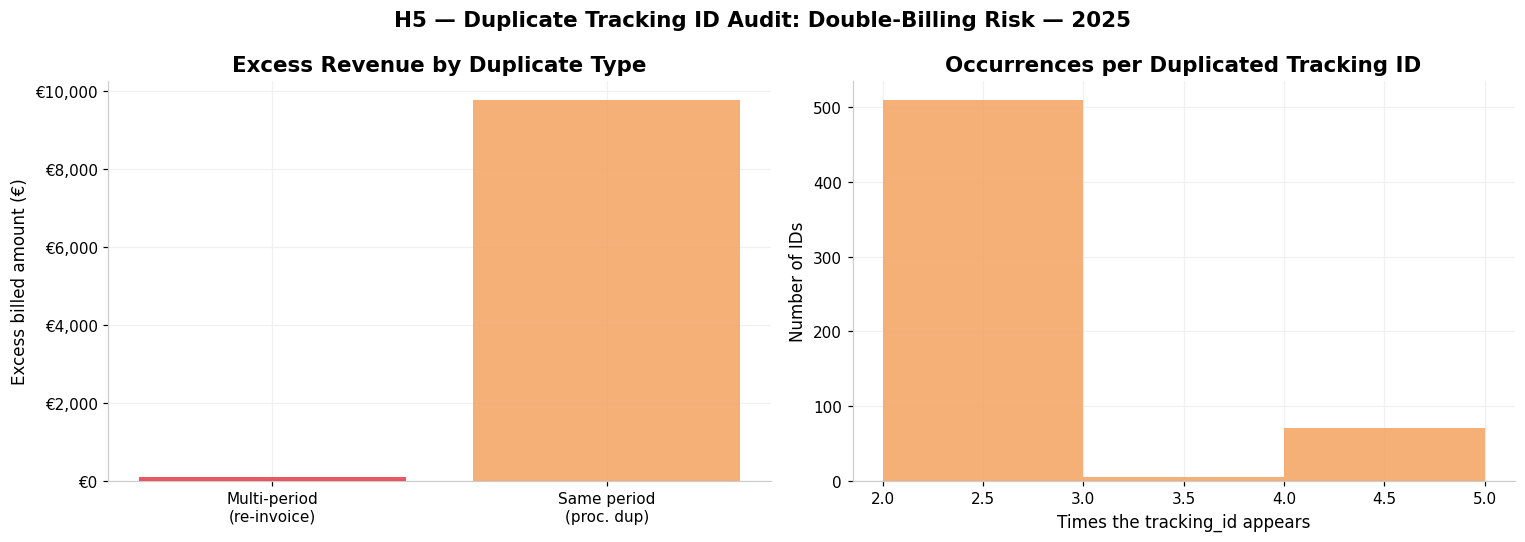

In [17]:
# ── H5: Duplicate tracking IDs — double-billing risk audit ───────────────────
dup_rever_all = rever[rever.duplicated("tracking_id", keep=False)].copy()

dup_grouped = (
    dup_rever_all.groupby("tracking_id")
    .agg(
        occurrences  = ("subtotal", "count"),
        total_billed = ("subtotal", "sum"),
        single_value = ("subtotal", "first"),
        n_periods    = ("invoicing_period", "nunique"),
    )
    .reset_index()
)
dup_grouped["excess_billed"] = dup_grouped["total_billed"] - dup_grouped["single_value"]

multi_period = dup_grouped[dup_grouped["n_periods"] > 1]
same_period  = dup_grouped[dup_grouped["n_periods"] == 1]

print(f"Duplicate tracking IDs total: {len(dup_grouped):,}")
print()
print(f"Multi-period (re-invoice risk): {len(multi_period):,} IDs")
print(f"  Total billed  : €{multi_period['total_billed'].sum():,.0f}")
print(f"  Excess billed : €{multi_period['excess_billed'].sum():,.0f}  ← potential double-billing")
print()
print(f"Same-period (processing dup): {len(same_period):,} IDs")
print(f"  Excess billed : €{same_period['excess_billed'].sum():,.0f}")
print()
print(f"Total excess revenue at risk: €{dup_grouped['excess_billed'].sum():,.0f}")
print()
print("Top 10 by excess billed:")
print(dup_grouped.sort_values("excess_billed", ascending=False).head(10)[
    ["tracking_id", "occurrences", "total_billed", "excess_billed", "n_periods"]
].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

axes[0].bar(
    ["Multi-period\n(re-invoice)", "Same period\n(proc. dup)"],
    [multi_period["excess_billed"].sum(), same_period["excess_billed"].sum()],
    color=[PALETTE["negative"], PALETTE["accent"]], alpha=0.85, zorder=3
)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:,.0f}"))
axes[0].set_title("Excess Revenue by Duplicate Type")
axes[0].set_ylabel("Excess billed amount (€)")

axes[1].hist(dup_grouped["occurrences"],
             bins=range(2, min(dup_grouped["occurrences"].max() + 2, 20)),
             color=PALETTE["accent"], alpha=0.85, zorder=3)
axes[1].set_title("Occurrences per Duplicated Tracking ID")
axes[1].set_xlabel("Times the tracking_id appears")
axes[1].set_ylabel("Number of IDs")

fig.suptitle("H5 — Duplicate Tracking ID Audit: Double-Billing Risk — 2025",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()